## Final Project - Part 2 of 3

# Model Selection

I have chosen to continue my theme of spring-mass systems by going with an overdamped spring-mass system. 

df/dt = -(k/c)x + (1/c)F(t)

where k/c = 5000s^-1 (high damping rate)

F(t) = 10sin(t)N

x(0) = 1m

The system modeled is an overdamped spring-mass system that has been subjected to an external forcing function. Y(t) is the displacement, k is the spring constant, c is the damping coefficient, and f(t) is the varying external force. With a k/c ratio of 5000 the system will decay extremely quickly towards equilibrium. However the forcing function operates on a O(1) scale which visually results in negligible visual indication of the forcing function. This difference makes the system stiff.

# Stiffness Demonstration

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def df(t, y):
    k = 25000000
    c = 5000
    f = 10*np.sin(t)
    return -(k/c)*y + (1/c)*f

In [2]:
def euler_forward_method(h, t_start, t_end, y_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    
    # Set initial conditions
    y_values[0] = y_0
    
    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        # Update equations for Euler's Method
        y_values[i] = y_n + h * df(t_values[i-1], y_values[i-1])
    return t_values, y_values

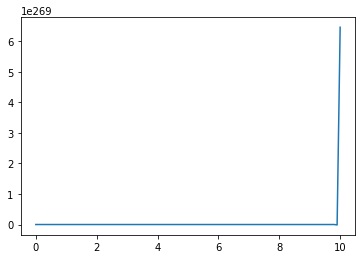

In [3]:
h = 0.1
t_start = 0
t_end = 10
y_0 = 1
t, y = euler_forward_method(h, t_start, t_end, y_0)
plt.plot(t, y, label=f'Euler\'s Forward (h={h})')

Although my system is linear, the ratio of eigenvalues does not accurately encompass the stiffness of this differential equation, so I will calculate the ratio of time scales. In this graph, the solution blows up to 1e269. That's not very good...

Using only the homogenous portion of the differential equation, f'(t) = (lambda)f(t) where f'(t) = -(5000)f(t), so abs(lambda) = 5000. This is an exponential relationship, so the time scale equals 1/lambda = 5000^-1.

Because the period of a sin function is equal to 2*pi/w and w = 1 (sin(1*t)), we know that our period is 6.28 which is O(1) and therefore a timescale of 1. 

This means our timescale ratio is 1/(5000^-1) = 5000. This system is stiff because it simulatenously holds fast decay rate but a slow sinusoidal forcing function.


# Euler's Backward Method with Newton-Raphson

To implement the Newton-Raphson method I need to utilize the residual function to approach my desired y(n+1):
g(y(n+1)) = y(n+1) - yn - (h)f(t(n+1),y(n+1))

and the derivative:
g'(y(n+1)) = y(n+1) - yn - (h)f(t(n+1),y(n+1))

Using this I can plug it back into my ODE where f'(t) = -5000, so:
g'(y(n+1)) = 1 + 5000(h)

Because the system is linear, the derivate g'(y) is constant. On top of this, a guess of y(0) = yn provides a guess for the iterating function. Therefore, the Newton-Raphson iterations converge extremely quickly towards the y(n+1) and allows it to be computationally efficient despite implicit computing and nested for loops.

In [4]:

def nr_method(i, y, t, h):
    # Explicit Euler Predictor, y(k=0)(n+1)=yn=y[i-1]
    ynew = y[i-1]
    iterations = 0
    for j in range(15):
        g = ynew - y[i-1] - h*df(t[i],ynew)
        gprime = 1 - h*(-5000)
        ynew = ynew - g/gprime
        iterations = j + 1
        if np.abs(g) < 1e-6:
            break
    return ynew, iterations

def euler_backward_method(h, t_start, t_end, y_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    iters = []
    # Set initial conditions
    y_values[0] = y_0
    
    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        # Update equations for Euler's Method
        y_values[i], iterations = nr_method(i, y_values, t_values, h)
        iters.append(iterations)
    return t_values, y_values, iters


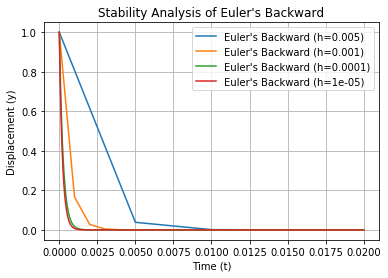

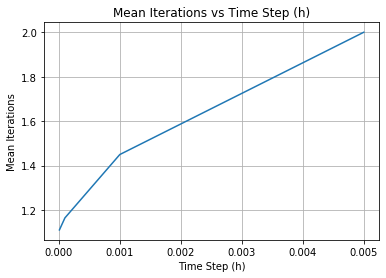

In [5]:
hs = [0.005, 0.001, 0.0001, 0.00001]
t_start = 0
t_end = 0.02
y_0 = 1
its = []

for h in hs:
    t, y, it = euler_backward_method(h, t_start, t_end, y_0)
    it = np.mean(it)
    its.append(it)
    plt.plot(t, y, label=f'Euler\'s Backward (h={h})')
    
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Euler\'s Backward')
plt.legend()
plt.grid(True)
plt.show()

plt.plot(hs, its)
plt.xlabel('Time Step (h)')
plt.ylabel('Mean Iterations')
plt.title('Mean Iterations vs Time Step (h)')
plt.grid(True)
plt.show()

# Stability Analysis and Comparison

As seen from the stability analysis, as h decreases so does the accuracy and the speed at which the system converges. However, after around h = 0.0001 there begins to be exponentially diminishing return per unit computing power. One of the reasons this is the case is because the average iteration per time step step decreases as h decreases, which aids in the system to converge faster and more accurately.

To compute the stable step size for euler foward I'm going to use the stability condition abs(1+(h)lambda) < 1. Solving -1 < 1 - 5000(h) < 1 allows me to solve both sides of the equation where 0 < h < 0.0004. For euler backward i can use the stability condition of abs(1/(1+5000(h))) < 1 which holds true for all h, there for h can be any number greater than zero and the implicit method is unconditionally stable. 

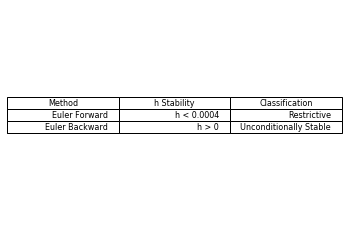

In [6]:
data = [["Euler Forward", "h < 0.0004", "Restrictive"], ["Euler Backward", "h > 0", "Unconditionally Stable"]]
columns = ('Method', 'h Stability', 'Classification')
rows = ['', '']
fig, ax = plt.subplots()
ax.axis('off')
the_table = ax.table(cellText=data,
                     rowLabels=rows,
                     colLabels=columns,
                     loc='center')
plt.show()

In [7]:
# Total Time Steps per h
totalsteps = np.full(len(hs), t_end)/hs
print("The total steps for Euler's backward method using h values of", hs, "are", totalsteps)

totalfuncevals = totalsteps*its
print("The total function evaluations for Euler's backward method using h values of", hs, "are", totalfuncevals)

The total steps for Euler's backward method using h values of [0.005, 0.001, 0.0001, 1e-05] are [   4.   20.  200. 2000.]
The total function evaluations for Euler's backward method using h values of [0.005, 0.001, 0.0001, 1e-05] are [   8.   29.  233. 2222.]


To compare the total computational cost of Euler's forward vs Euler's backward, we can the amount of times a for loop is iterated through.

For Euler's forward, it would require 0.02/0.0004 (where 0.02 is the time_end and 0.0004 is the h value) as a minimum stable total step count required for stability, which is a total of 50 steps, and 50 times a loop was iterated through. This results in about 50 function evaluations.

For Euler's backward, it would require 20 time steps with an h of 0.001, in which it would iterate through the newton-raphson method an average of about 1.45 iterations. this results in 29 function evaluations where each newton iteration is a function evaluation. Overall, Euler's backward is much more efficient, even with the nested for loops from the newton iterations.

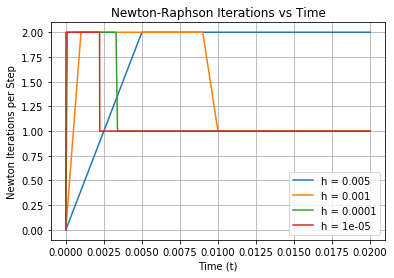

In [8]:
plt.figure()

for h in hs:
    t, y, it = euler_backward_method(h, t_start, t_end, y_0)
    it_full = np.concatenate(([0], it)) 
    plt.plot(t, it_full, label=f'h = {h}')

plt.xlabel('Time (t)')
plt.ylabel('Newton Iterations per Step')
plt.title('Newton-Raphson Iterations vs Time')
plt.grid(True)
plt.legend()
plt.show()

Analytical Solution

Yp = (A)sin(t)+(B)cos(t)

Yp' = (A)sin(t)+(B)cos(t) so (A)cos(t)-(B)sin(t) + 5000((A)sin(t)+(B)cos(t))= (0.002)sin(t)

A+5000B = 0, 5000A = B + 0.002

A = 4e-7, B = -8e-11, C = (Y_0 - B)

In [9]:
# Actual Solution
def f(t):
    A = 4e-7
    B = -8e-11
    C = y_0
    return C*np.exp(-5000*t)+A*np.sin(t)+B*np.cos(t)

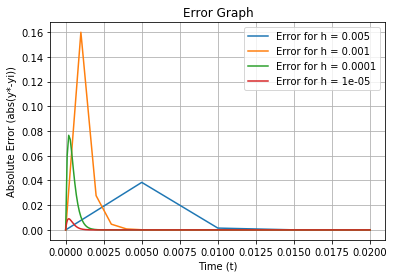

In [10]:
# Error Graphing
plt.figure()
for h in hs:
    t, Y, it = euler_backward_method(h, t_start, t_end, y_0)
    error = np.abs(Y - f(t))
    plt.plot(t, error, label='Error for h = ' + str(h))
    
plt.title("Error Graph")
plt.xlabel("Time (t)")
plt.ylabel("Absolute Error (abs(y*-yi))")
plt.grid()
plt.legend()
plt.show()

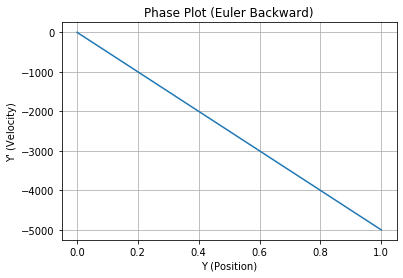

In [11]:
# Phase Portrait
for h in hs:
    t, y, it = euler_backward_method(h, t_start, t_end, y_0)
    # y'
    y_dot = np.array([df(t[i], y[i]) for i in range(len(t))])

plt.plot(y, y_dot)
plt.xlabel('Y (Position)')
plt.ylabel("Y' (Velocity)")
plt.title("Phase Plot (Euler Backward)")
plt.grid(True)
plt.show()

# Conclusion

Through this project I was able to see the benefit of implicit computing methods with stiff systems that have greatly varying time scales. Euler's forward method required extremely small step sizes (h < 0.0004) to maintain stability which greatly increased computational cost whereas Euler's backward method was unconditionally stable and allowed for larger, but still accurate, step sizes. The Newton=Raphson method within the Euler Backward method enabled efficient solution due to its linear nature. It converges extremely quickly to the given error and as a result the overall computation cost of Euler's Backward is less than that of the explicit method despite having nested functions/for-loops. This project showed that implicit methods are better suited for solving stiff ODE's and portraying fast dynamics.